In [60]:
import itertools
import re
import warnings

import nltk
import numpy as np
import pandas as pd
import spacy
from bs4 import BeautifulSoup
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from nltk.corpus import stopwords
from top2vec import Top2Vec

In [3]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 8.5 MB/s eta 0:00:02
     ------------------------- -------------- 8.1/12.8 MB 36.1 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 34.9 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## Top2Vec

In [4]:
# Carga de datos
test = pd.read_csv("data/research-articles/test.csv")
train = pd.read_csv("data/research-articles/train.csv")

display(test.head())
display(train.head())

,ID,TITLE,ABSTRACT
0,20973,Closed-form Marginal Likelihood in Gamma-Poiss...,We present novel understandings of the Gamma...
1,20974,Laboratory mid-IR spectra of equilibrated and ...,Meteorites contain minerals from Solar Syste...
2,20975,Case For Static AMSDU Aggregation in WLANs,Frame aggregation is a mechanism by which mu...
3,20976,The $Gaia$-ESO Survey: the inner disk intermed...,Milky Way open clusters are very diverse in ...
4,20977,Witness-Functions versus Interpretation-Functi...,Proving that a cryptographic protocol is cor...


,ID,TITLE,ABSTRACT,Computer Science,Physics,Mathematics,Statistics,Quantitative Biology,Quantitative Finance
0,1,Reconstructing Subject-Specific Effect Maps,Predictive models allow subject-specific inf...,1,0,0,0,0,0
1,2,Rotation Invariance Neural Network,Rotation invariance and translation invarian...,1,0,0,0,0,0
2,3,Spherical polyharmonics and Poisson kernels fo...,We introduce and develop the notion of spher...,0,0,1,0,0,0
3,4,A finite element approximation for the stochas...,The stochastic Landau--Lifshitz--Gilbert (LL...,0,0,1,0,0,0
4,5,Comparative study of Discrete Wavelet Transfor...,Fourier-transform infra-red (FTIR) spectra o...,1,0,0,1,0,0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20972 entries, 0 to 20971
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    20972 non-null  int64 
 1   TITLE                 20972 non-null  object
 2   ABSTRACT              20972 non-null  object
 3   Computer Science      20972 non-null  int64 
 4   Physics               20972 non-null  int64 
 5   Mathematics           20972 non-null  int64 
 6   Statistics            20972 non-null  int64 
 7   Quantitative Biology  20972 non-null  int64 
 8   Quantitative Finance  20972 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 1.4+ MB


In [6]:
train.dtypes

ID                       int64
TITLE                   object
ABSTRACT                object
Computer Science         int64
Physics                  int64
Mathematics              int64
Statistics               int64
Quantitative Biology     int64
Quantitative Finance     int64
dtype: object

In [7]:
documents = list(train.ABSTRACT.values) # utilizaremos solo la columan Abstract como los documentos
print(documents[0]) # como ejemplo imprimimos el primer documento

  Predictive models allow subject-specific inference when analyzing disease
related alterations in neuroimaging data. Given a subject's data, inference can
be made at two levels: global, i.e. identifiying condition presence for the
subject, and local, i.e. detecting condition effect on each individual
measurement extracted from the subject's data. While global inference is widely
used, local inference, which can be used to form subject-specific effect maps,
is rarely used because existing models often yield noisy detections composed of
dispersed isolated islands. In this article, we propose a reconstruction
method, named RSM, to improve subject-specific detections of predictive
modeling approaches and in particular, binary classifiers. RSM specifically
aims to reduce noise due to sampling error associated with using a finite
sample of examples to train classifiers. The proposed method is a wrapper-type
algorithm that can be used with different binary classifiers in a diagnostic
manner,

In [8]:
nltk.download('stopwords')
stop_words_en = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\zeldan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
## Cargar modelo de spaCy en ingles
nlp = spacy.load("en_core_web_sm")
custom_stops = {
    "research", "paper", "study", "result", "analysis", "method",
    "approach", "system", "data", "based", "user", "model"
}

def remove_html(_text):
    no_html_txt = BeautifulSoup(_text, "html.parser").getText(separator=" ")
    return no_html_txt

def clear_text(_text):
    #Eliminar etiquetas html
    _text = remove_html(_text)

    # Limpieza basica del texto
    ## Eliminar bloques de código entre ```
    _text = re.sub(r"```.*?```", " ", _text, flags=re.DOTALL)

    ##Eliminar etiquetas markdown (#, *, _, >, etc.)
    _text = re.sub(r"[#*_>\-`~]", " ", _text)

    ##Eliminar URLs y direcciones tipo http o www
    _text = re.sub(r"http\S+|www\S+", " ", _text)

    ##Eliminar etiquetas HTML o imágenes ![texto](url)
    _text = re.sub(r"!\[.*?\]\(.*?\)", " ", _text)

    ##quitar números y caracteres no alfabéticos (mantener letras acentuadas)
    texto = re.sub(r"[^a-zA-ZáéíóúñÁÉÍÓÚüÜ\s]", " ", _text)

    ##texto a minusculas para hacer mejores comparaciones
    _text = _text.lower()

    # Eliminacion de stopwords
    doc = nlp(_text) # retorna un objeto con estructura de tokens, lemas, etiquetas (analizado)

    tokens = [] # para guardar palablas sin stopwords
    for word in doc:
        if (
            word.is_alpha and
            not word.is_punct and
            not word.is_space
        ):
            if not word.is_stop and word.lemma_.lower() not in stop_words_en:
                # si la palabra esta formada por letras(no numeros o signos)
                # word.lemma_ -> forma raiz de la palabra
                tokens.append(word.lemma_.lower())

    return " ".join(tokens)

In [10]:
clean_text  = []
for d in documents:
    txt = clear_text(d)
    clean_text.append(txt)

df_clean_docs = pd.DataFrame({
    "texto": clean_text
})
df_clean_docs["num_palabras"] = df_clean_docs["texto"].apply(lambda x: len(x.split()))
print(df_clean_docs.shape)
df_clean_docs.head()

(20972, 2)


,texto,num_palabras
0,predictive model allow subject specific infere...,170
1,rotation invariance translation invariance gre...,43
2,introduce develop notion spherical polyharmoni...,56
3,stochastic landau lifshitz gilbert llg equatio...,65
4,fouri transform infra red ftir spectra sample ...,81


In [29]:
documents = clean_text
tokenized_texts = [doc.split() for doc in clean_text]
dictionary = Dictionary(tokenized_texts)
dictionary.filter_extremes(no_below=5, no_above=0.8)

In [30]:
def coherence_score(_topic_words,_texts,_dictionary):
    # Filtrar palabras que NO estén en el diccionario
    filtered_topics = []
    for topic in _topic_words:
        filtered = [w for w in topic if w in _dictionary.token2id]
        filtered_topics.append(filtered)
    return CoherenceModel(
        topics=filtered_topics,
        texts=_texts,
        dictionary=_dictionary,
        coherence='c_v'
    ).get_coherence()

In [31]:
def train_top2vec_and_get_coherence(_speed, _min_count):
    # Entrenar el modelo
    model =  Top2Vec(documents=documents,
                     speed=_speed,
                     min_count=_min_count,
                      workers=4)

    # Obtener info de temas
    topic_sizes, topic_nums = model.get_topic_sizes()
    words, word_scores, ids = model.get_topics()

    # Calcular coherencia
    topic_words = []
    for w_list in words:
        topic_words.append(w_list[:10])  # top 10

    coherence  = coherence_score(topic_words, tokenized_texts, dictionary)
    return {
        "model": model,
        "n_topics": len(topic_words),
        "avg_topic_size": np.mean(topic_sizes),
        "coherence": coherence,
        "topic_words": topic_words
    }

In [34]:
results = []
param_grid = {
    "speed": ["fast-learn", "learn"],
    "min_count": [5, 10],
}

results = []

for speed, mcount in itertools.product(
        param_grid["speed"],
        param_grid["min_count"]
    ):

    print(f"Probando conf:  speed={speed}, min_count={mcount}")

    out = train_top2vec_and_get_coherence(
        _speed=speed,
        _min_count=mcount
    )

    results.append({
        "speed": speed,
        "min_count": mcount,
        "n_topics": out["n_topics"],
        "avg_topic_size": out["avg_topic_size"],
        "coherence": out["coherence"],
        "topic_words": out["topic_words"],
        "model": out["model"]
    })

df_results = pd.DataFrame(results)
df_results

2025-11-18 23:00:58,648 - top2vec - INFO - Pre-processing documents for training


Probando conf:  speed=fast-learn, min_count=5


C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2025-11-18 23:01:01,173 - top2vec - INFO - Downloading all-MiniLM-L6-v2 model
2025-11-18 23:01:03,377 - top2vec - INFO - Creating joint document/word embedding
2025-11-18 23:04:37,626 - top2vec - INFO - Creating lower dimension embedding of documents
2025-11-18 23:04:40,022 - top2vec - INFO - Finding dense areas of documents
C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-11-18 23:04:40,373 - top2ve

Probando conf:  speed=fast-learn, min_count=10


C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2025-11-18 23:04:54,109 - top2vec - INFO - Downloading all-MiniLM-L6-v2 model
2025-11-18 23:04:55,931 - top2vec - INFO - Creating joint document/word embedding
2025-11-18 23:08:19,749 - top2vec - INFO - Creating lower dimension embedding of documents
2025-11-18 23:08:21,653 - top2vec - INFO - Finding dense areas of documents
C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-11-18 23:08:21,977 - top2ve

Probando conf:  speed=learn, min_count=5


C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2025-11-18 23:08:34,299 - top2vec - INFO - Downloading all-MiniLM-L6-v2 model
2025-11-18 23:08:37,056 - top2vec - INFO - Creating joint document/word embedding
2025-11-18 23:12:00,571 - top2vec - INFO - Creating lower dimension embedding of documents
2025-11-18 23:12:02,317 - top2vec - INFO - Finding dense areas of documents
C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-11-18 23:12:02,635 - top2ve

Probando conf:  speed=learn, min_count=10


C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2025-11-18 23:12:14,937 - top2vec - INFO - Downloading all-MiniLM-L6-v2 model
2025-11-18 23:12:17,200 - top2vec - INFO - Creating joint document/word embedding
2025-11-18 23:15:39,231 - top2vec - INFO - Creating lower dimension embedding of documents
2025-11-18 23:15:40,972 - top2vec - INFO - Finding dense areas of documents
C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-11-18 23:15:41,303 - top2ve

,speed,min_count,n_topics,avg_topic_size,coherence,topic_words,model
0,fast-learn,5,137,153.080292,0.389939,"[[imagenet, tensorflow, cnns, convnet, cnn, ne...",<top2vec.top2vec.Top2Vec object at 0x000001EDC...
1,fast-learn,10,147,142.666667,0.408688,"[[noncommutative, subalgebra, lusztig, grassma...",<top2vec.top2vec.Top2Vec object at 0x000001EDB...
2,learn,5,134,156.507463,0.389750,"[[astrophysical, astronomy, astronomical, gala...",<top2vec.top2vec.Top2Vec object at 0x000001EDB...
3,learn,10,140,149.800000,0.407575,"[[imagenet, tensorflow, cnns, convnet, neural,...",<top2vec.top2vec.Top2Vec object at 0x000001EDB...


In [39]:
best = df_results.loc[df_results["coherence"].idxmax()]
best

speed                                                    fast-learn
min_count                                                        10
n_topics                                                        147
avg_topic_size                                           142.666667
coherence                                                  0.408688
topic_words       [[noncommutative, subalgebra, lusztig, grassma...
model             <top2vec.top2vec.Top2Vec object at 0x000001EDB...
Name: 1, dtype: object

In [52]:
best_model = best["model"]


In [53]:
topic_words_clean = []

for topic in best_model.topic_words:
    topic_words_clean.append(topic[:10])  # top 10 palabras

df_topics = pd.DataFrame({
    "Topic": [f"Tema {i}" for i in range(len(topic_words_clean))],
    "Words": [", ".join(t) for t in topic_words_clean]
})

df_topics.head()

,Topic,Words
0,Tema 0,"noncommutative, subalgebra, lusztig, grassmann..."
1,Tema 1,"imagenet, tensorflow, cnns, convnet, cnn, neur..."
2,Tema 2,"manifolds, manifold, cohomology, projective, c..."
3,Tema 3,"formalization, specification, automata, comput..."
4,Tema 4,"ferromagnetic, nonmagnetic, ferromagnet, ferro..."


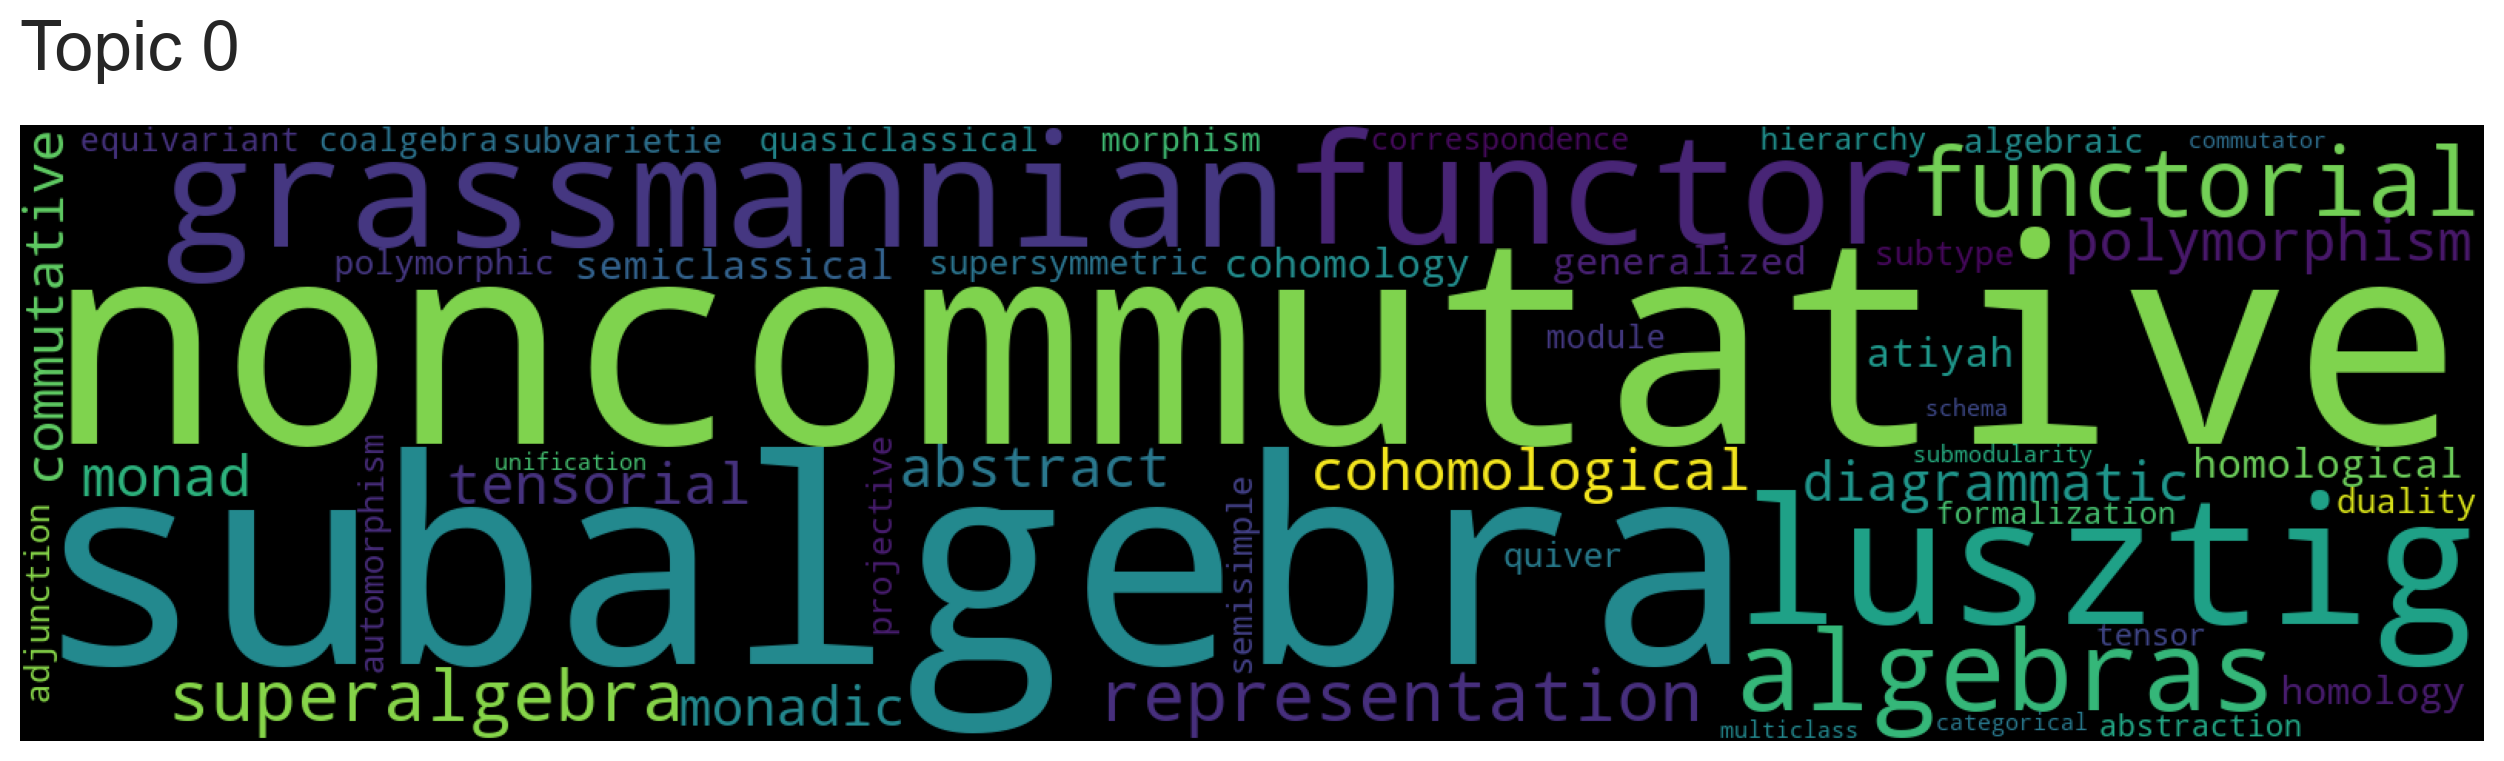

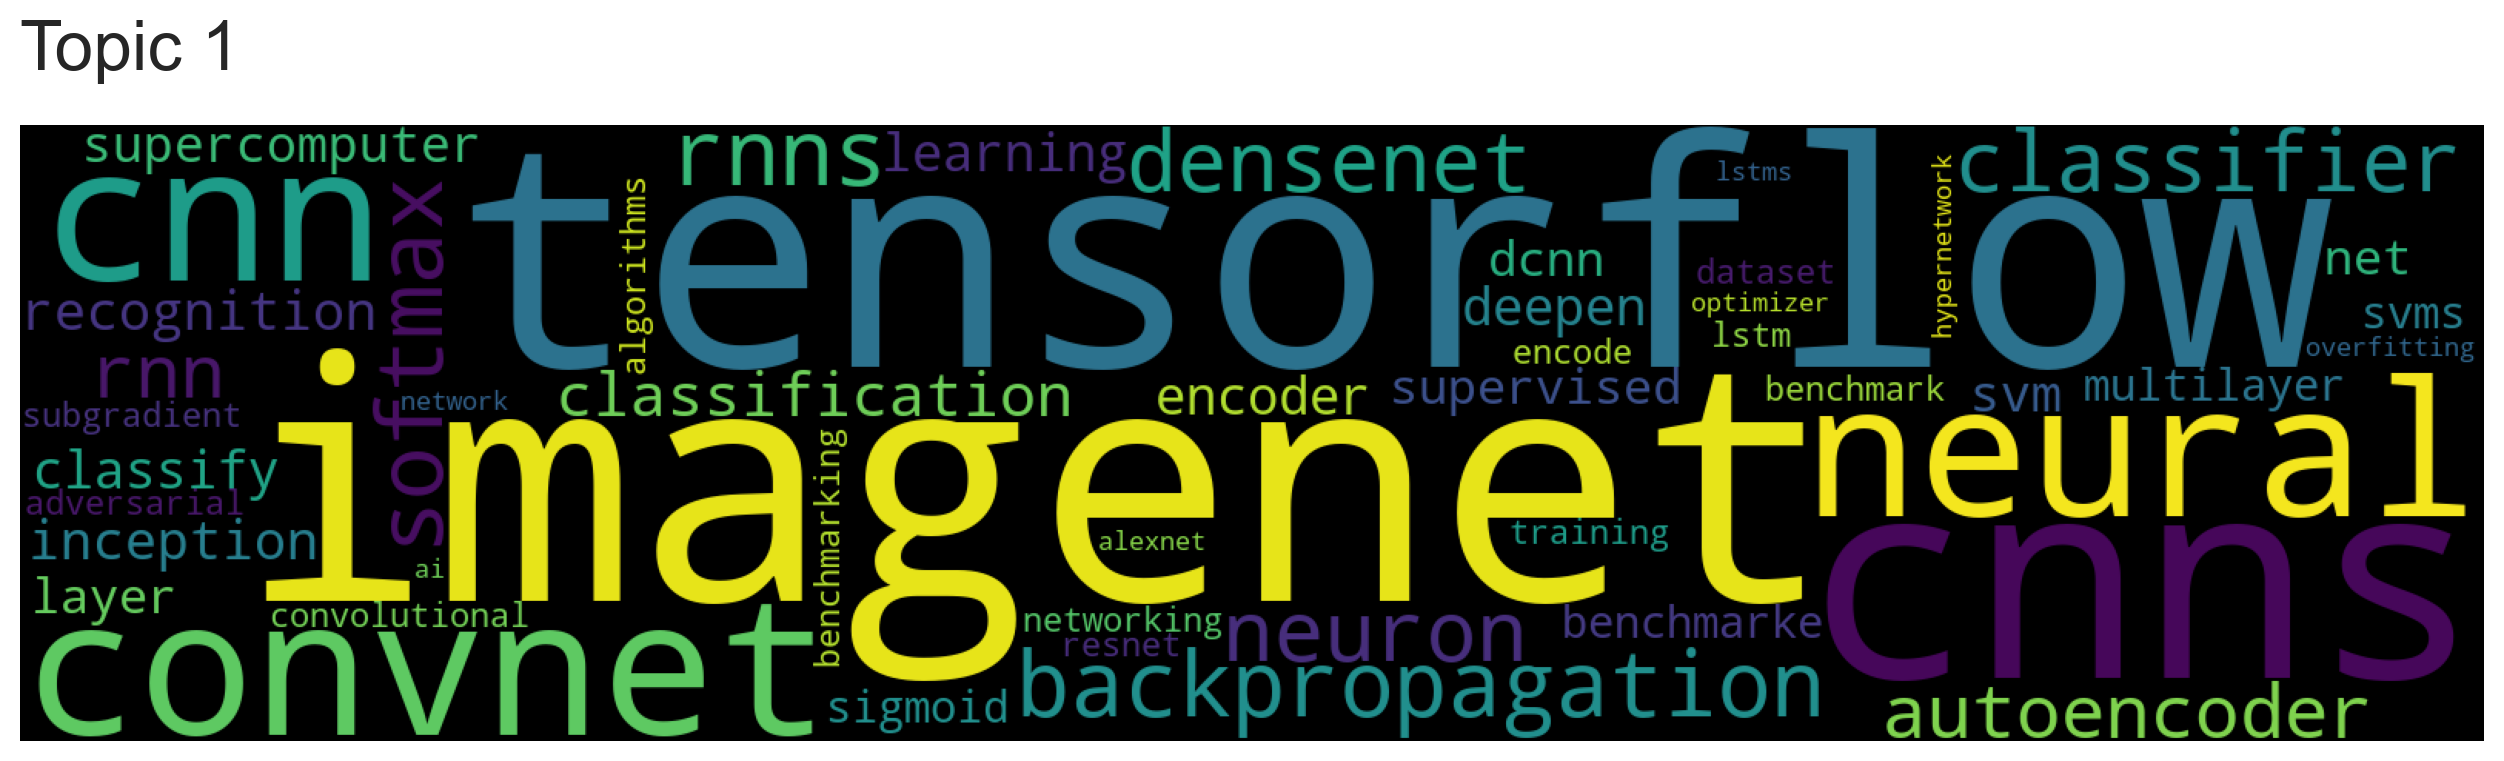

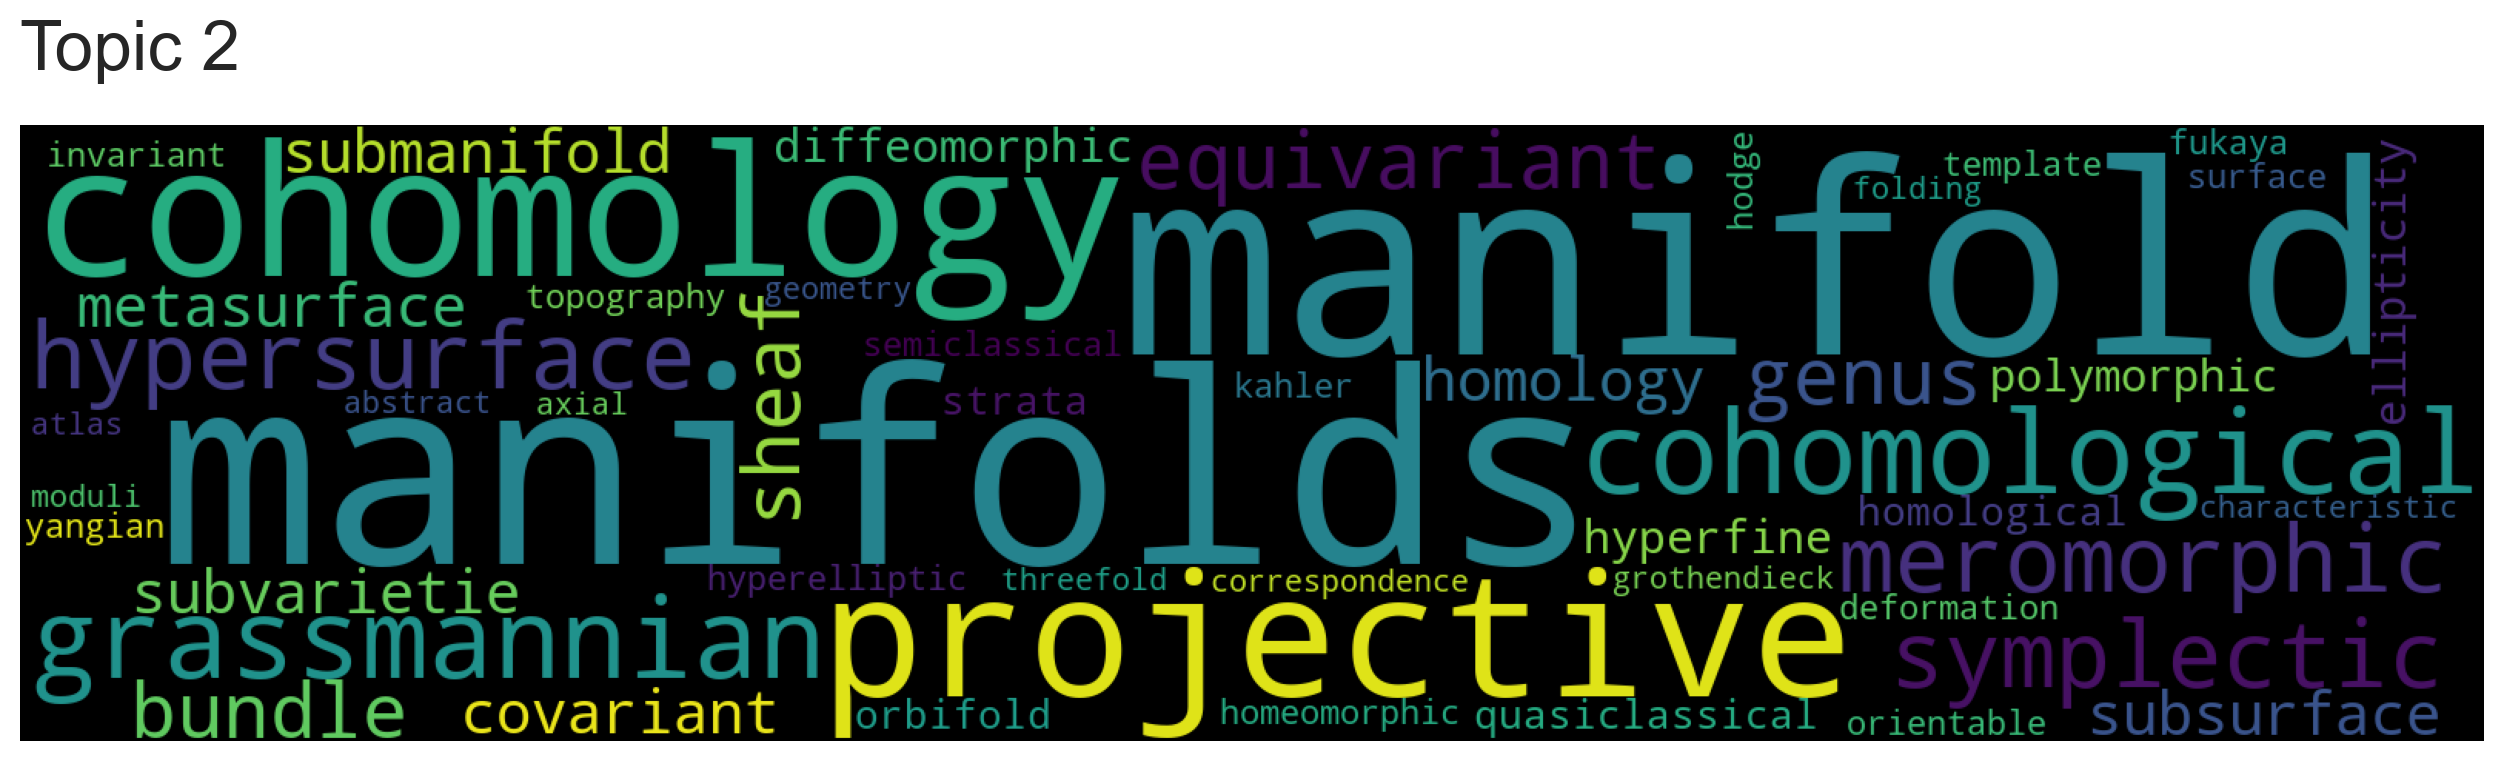

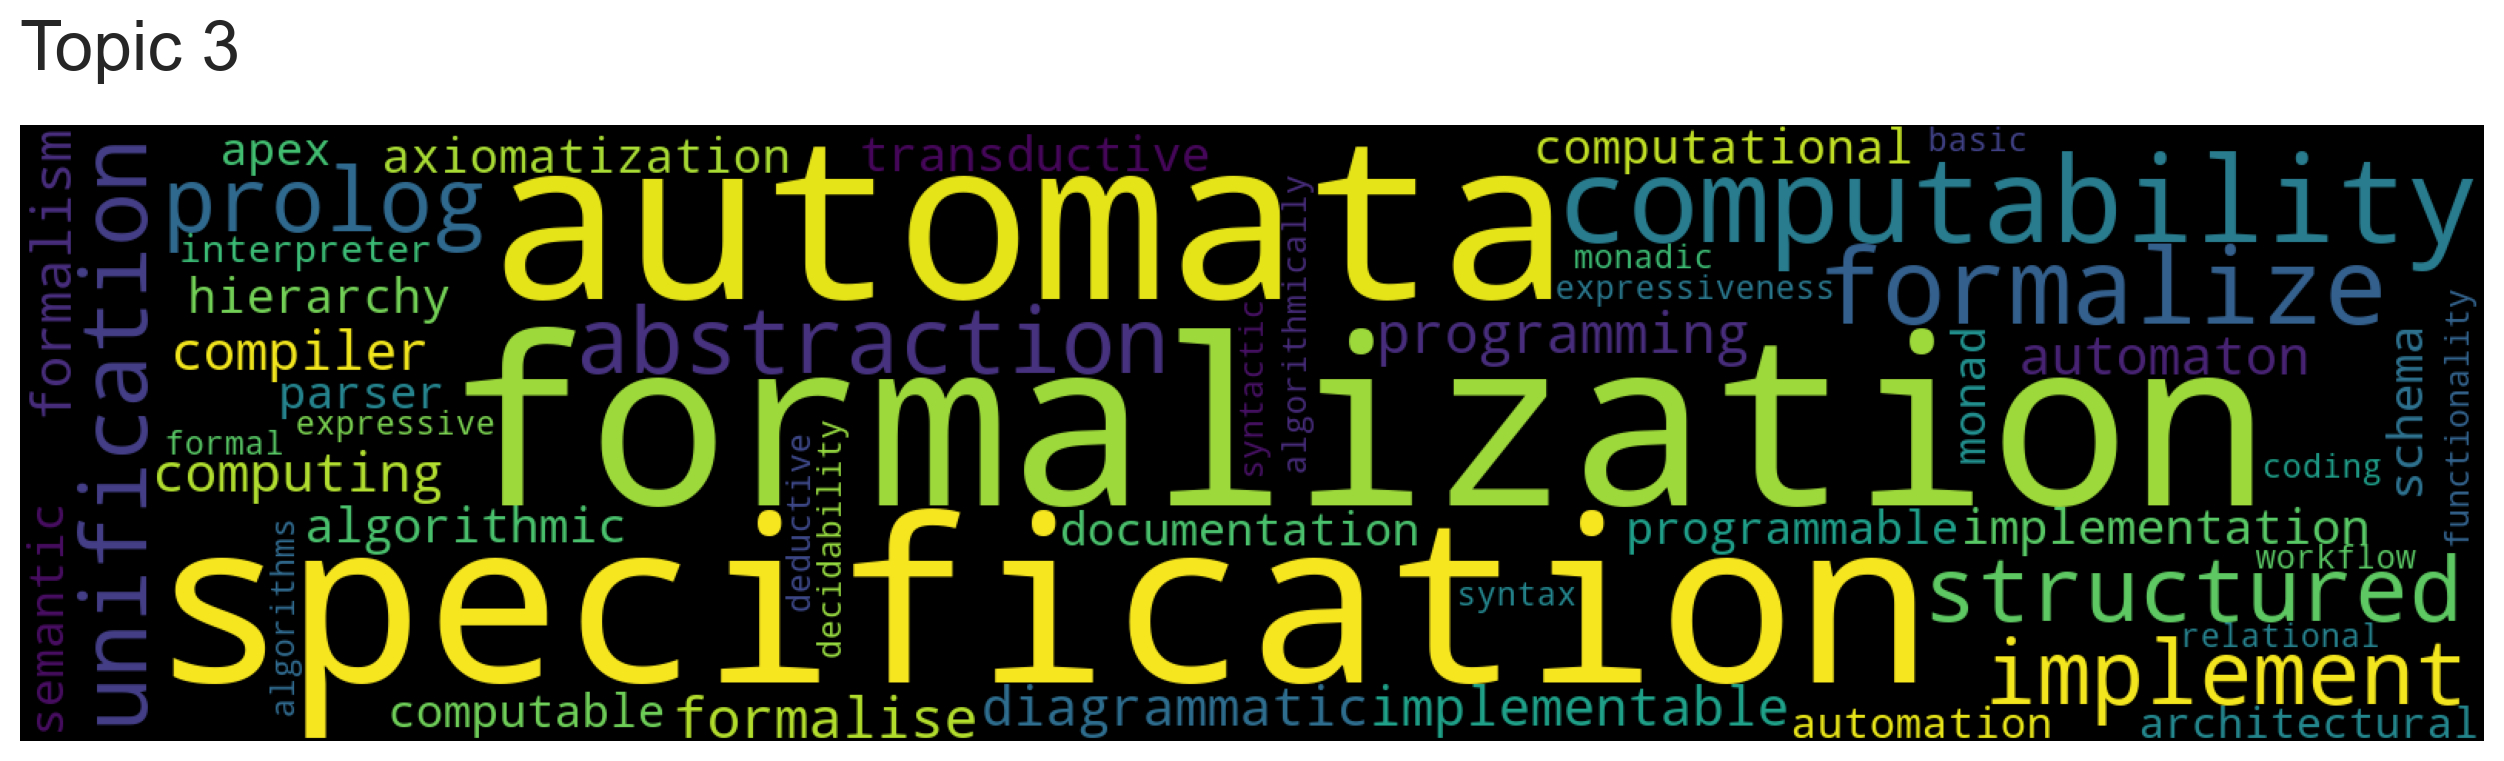

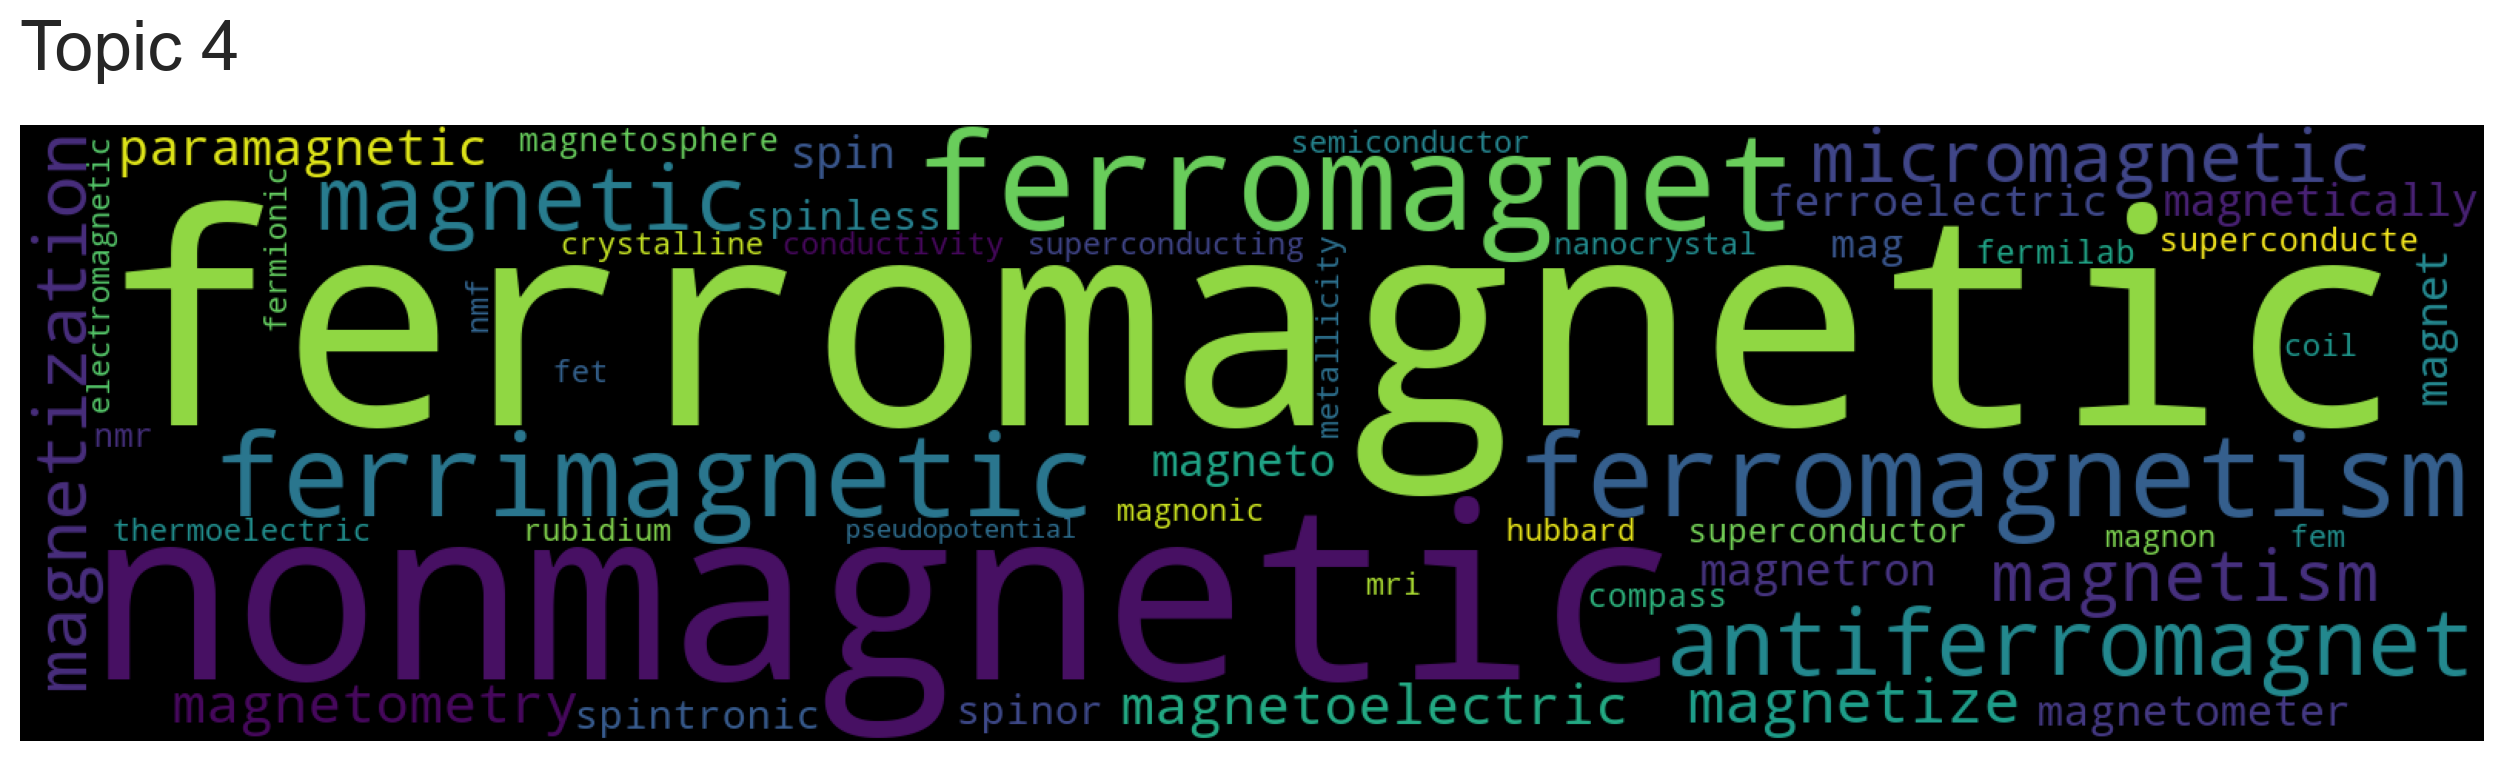

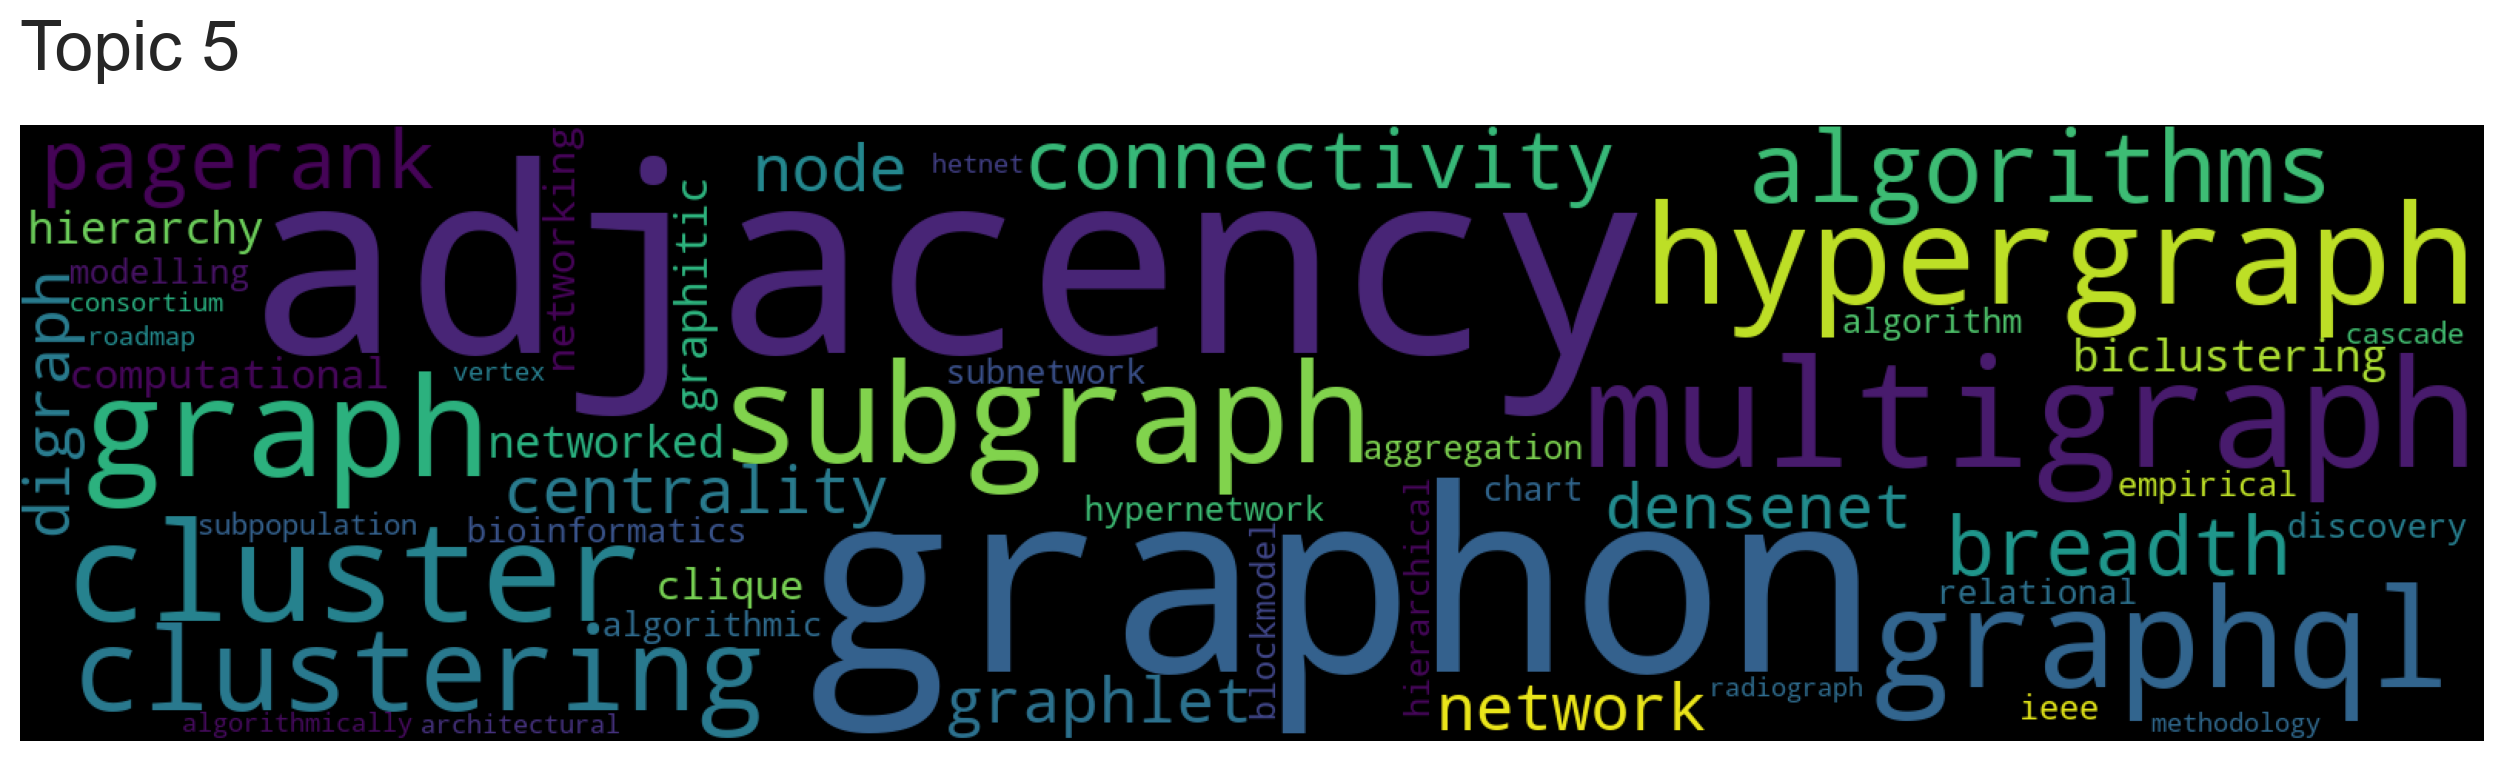

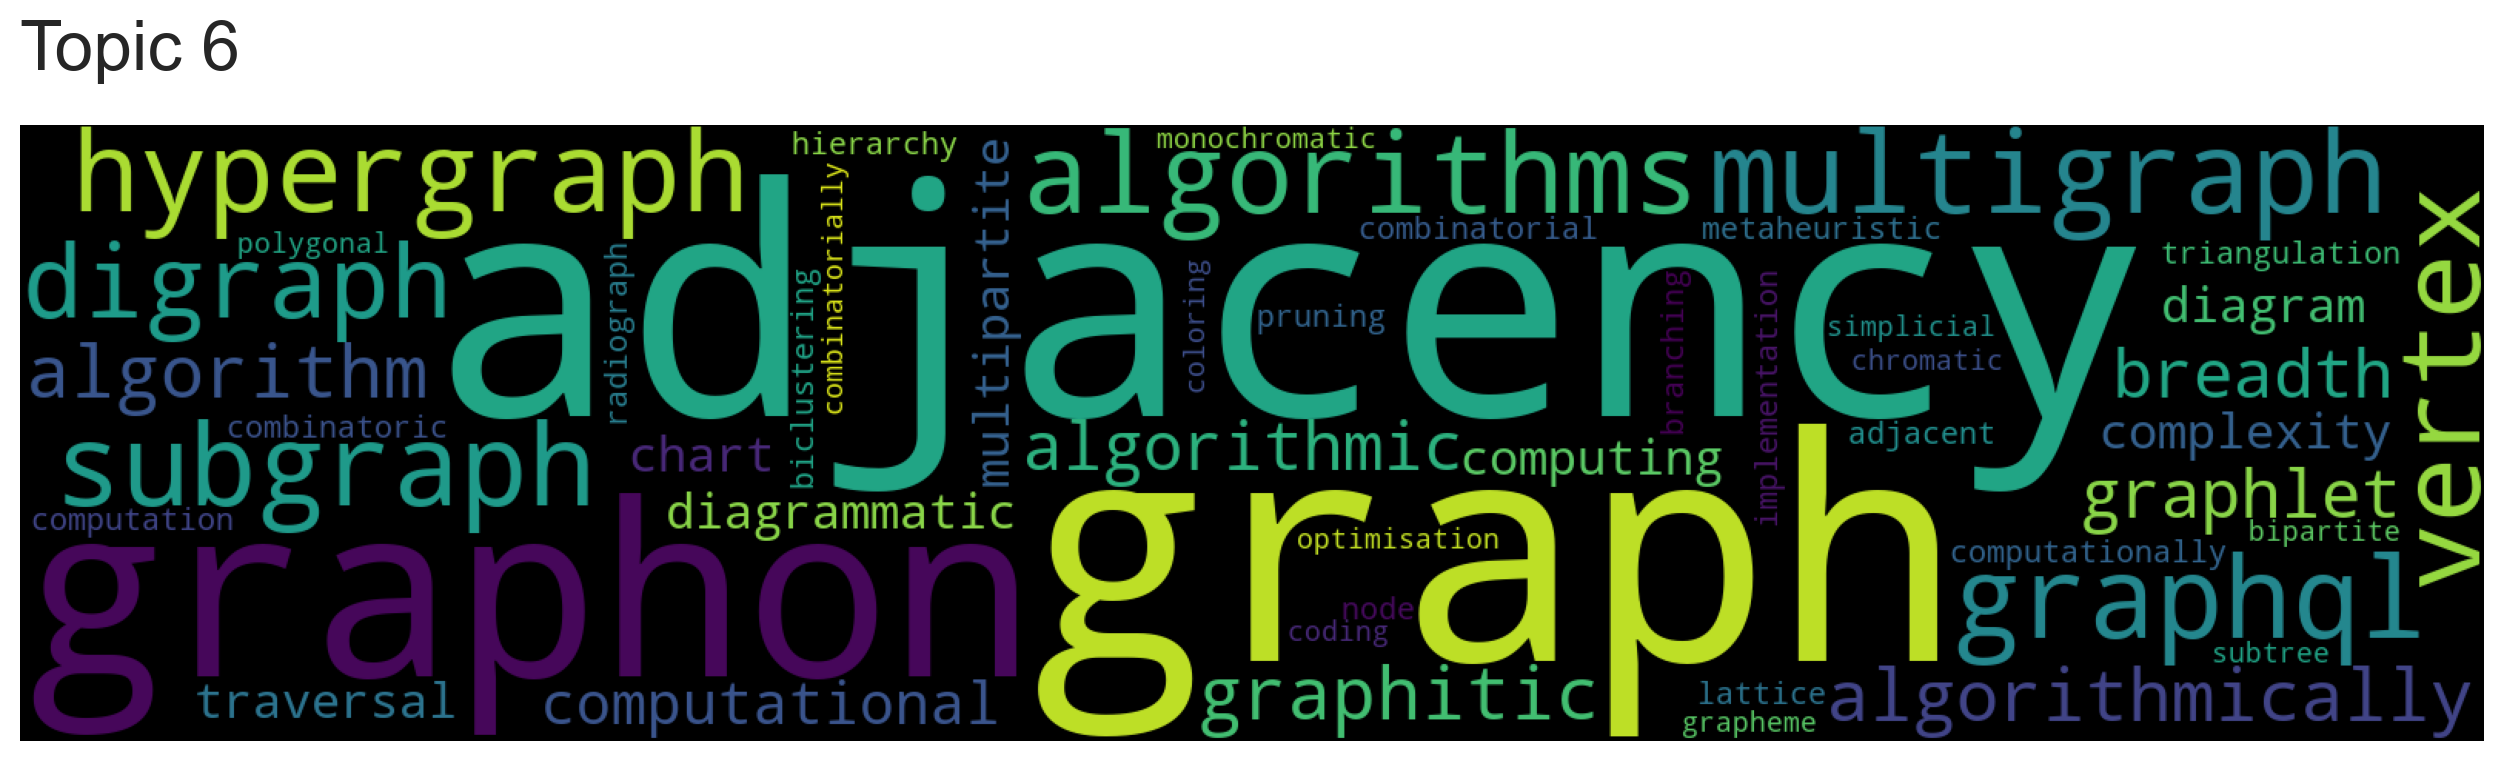

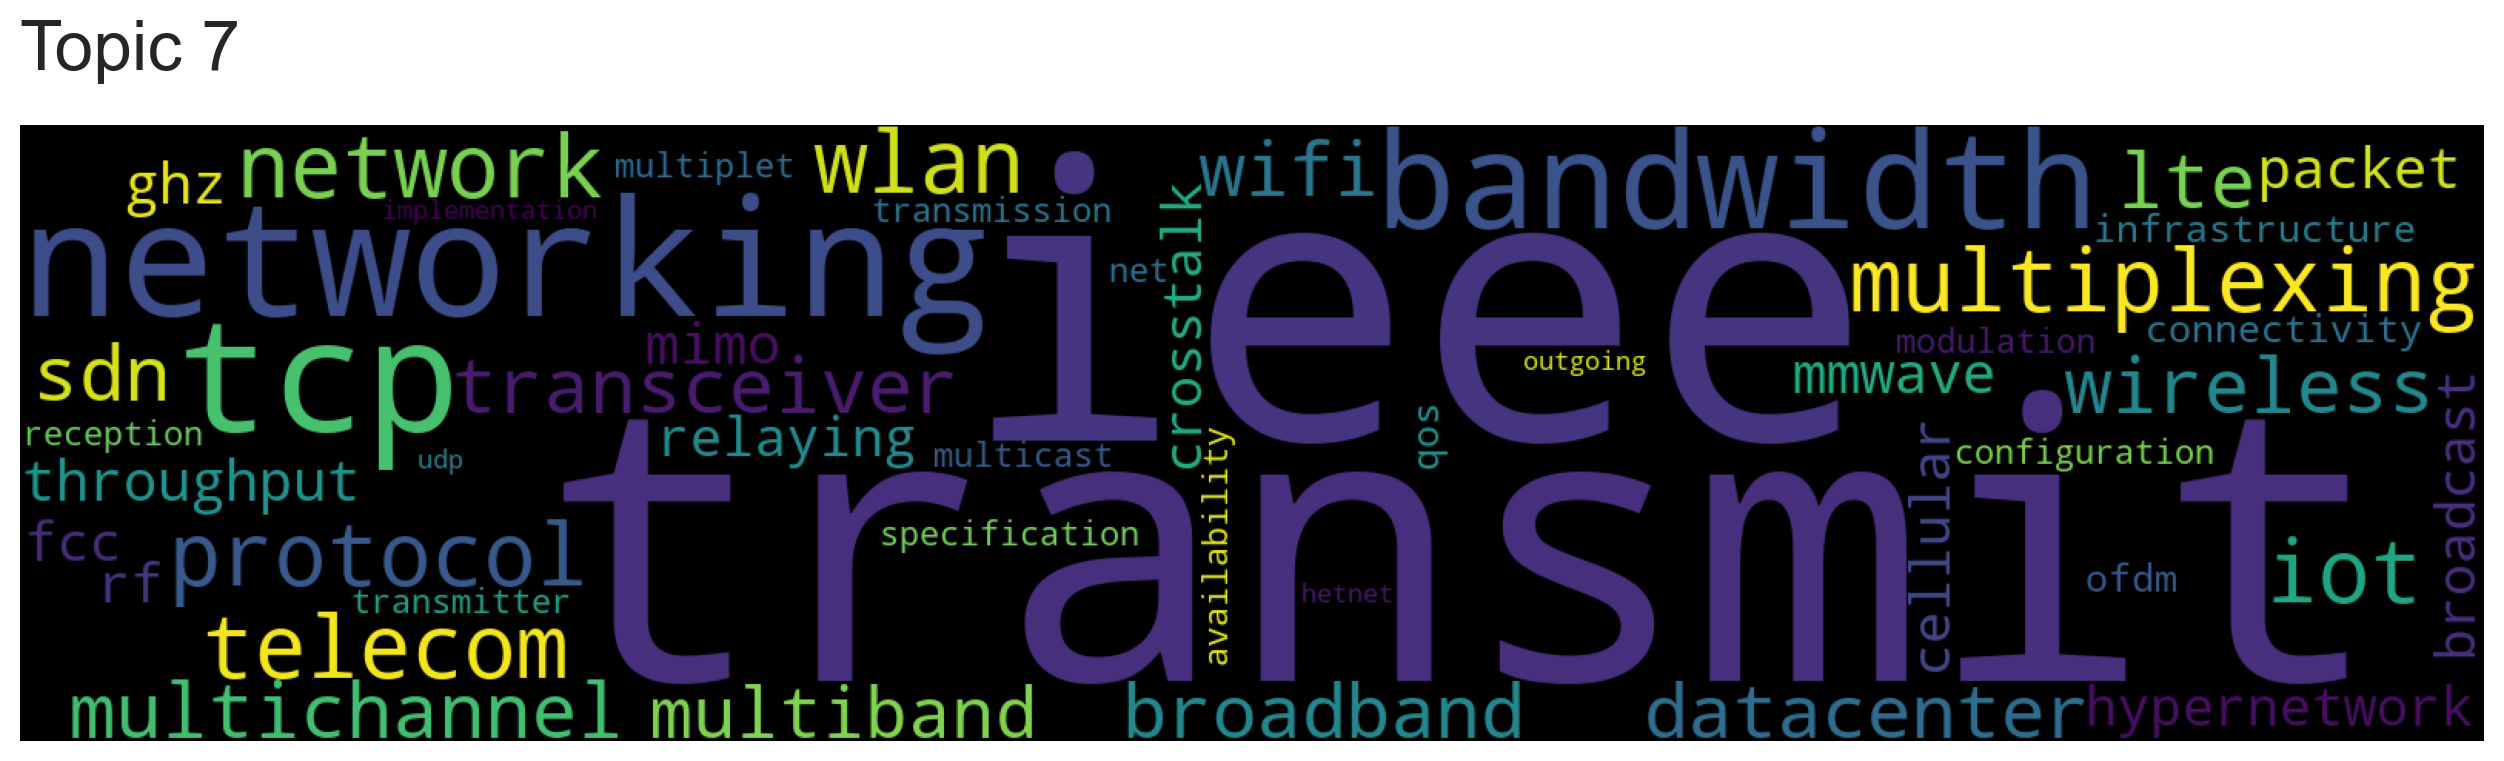

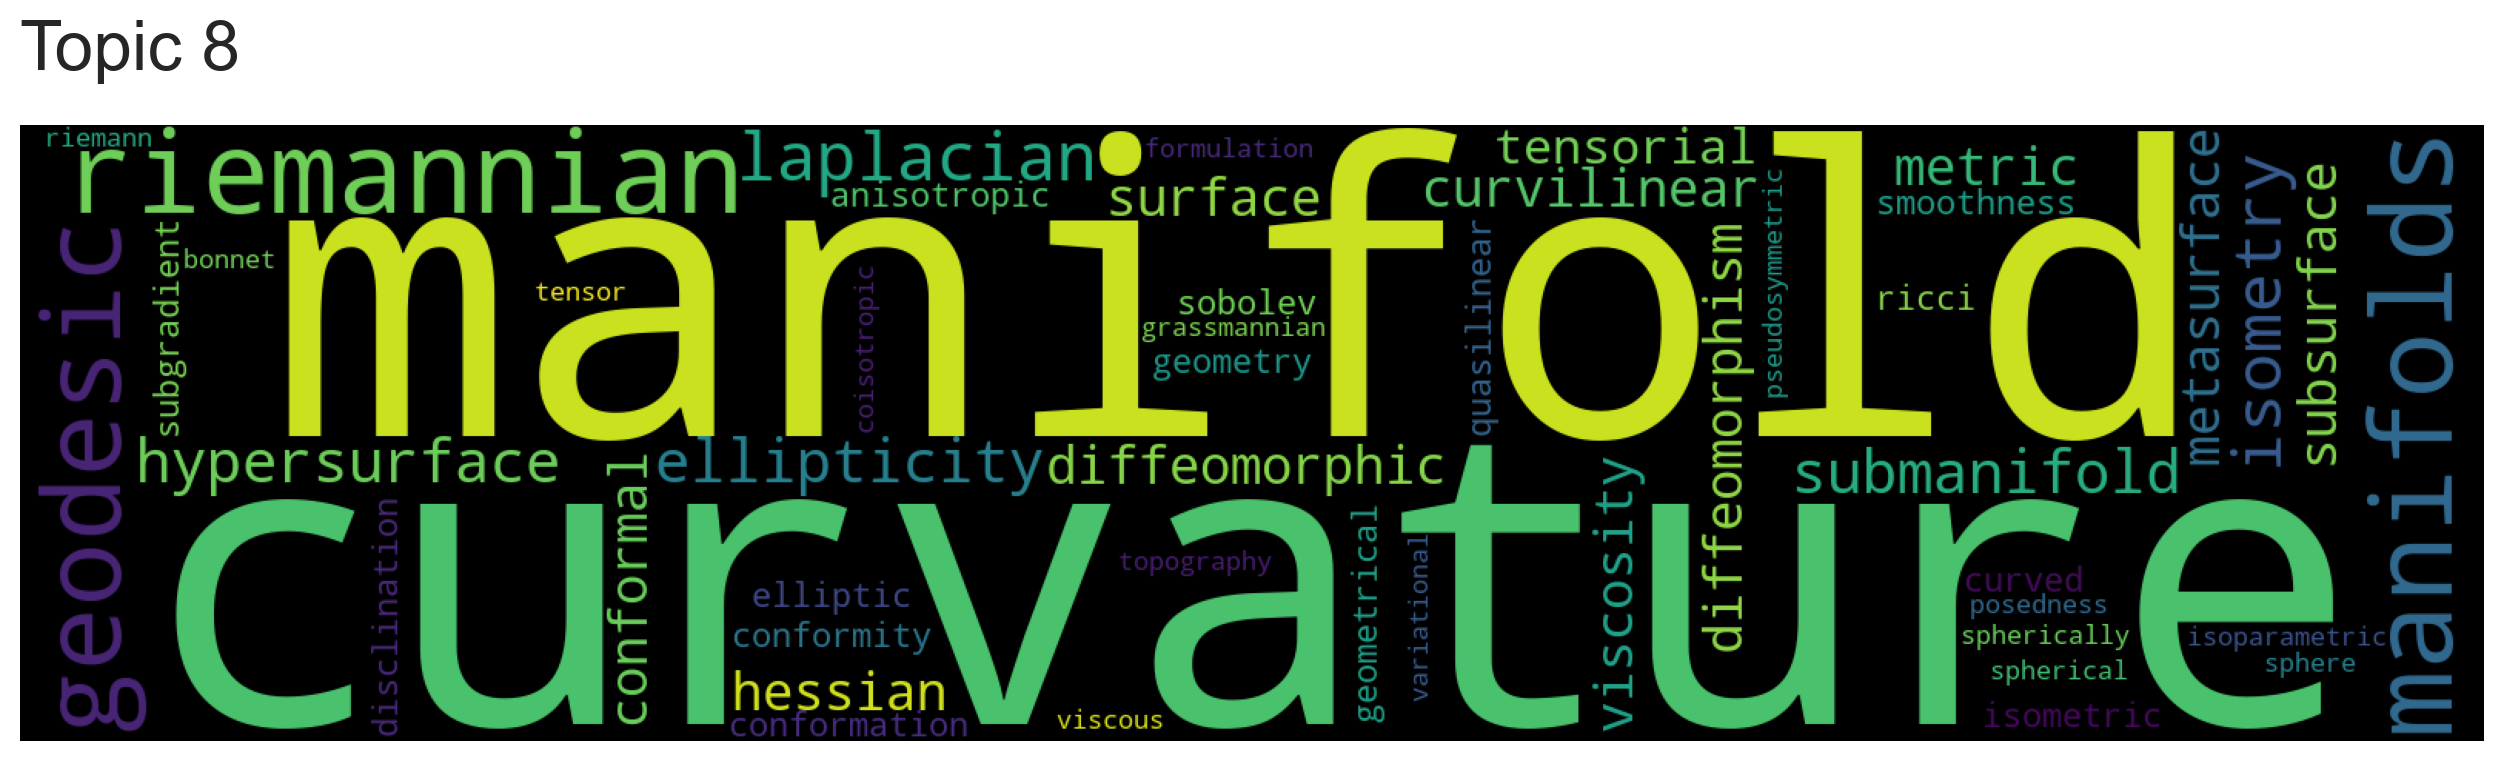

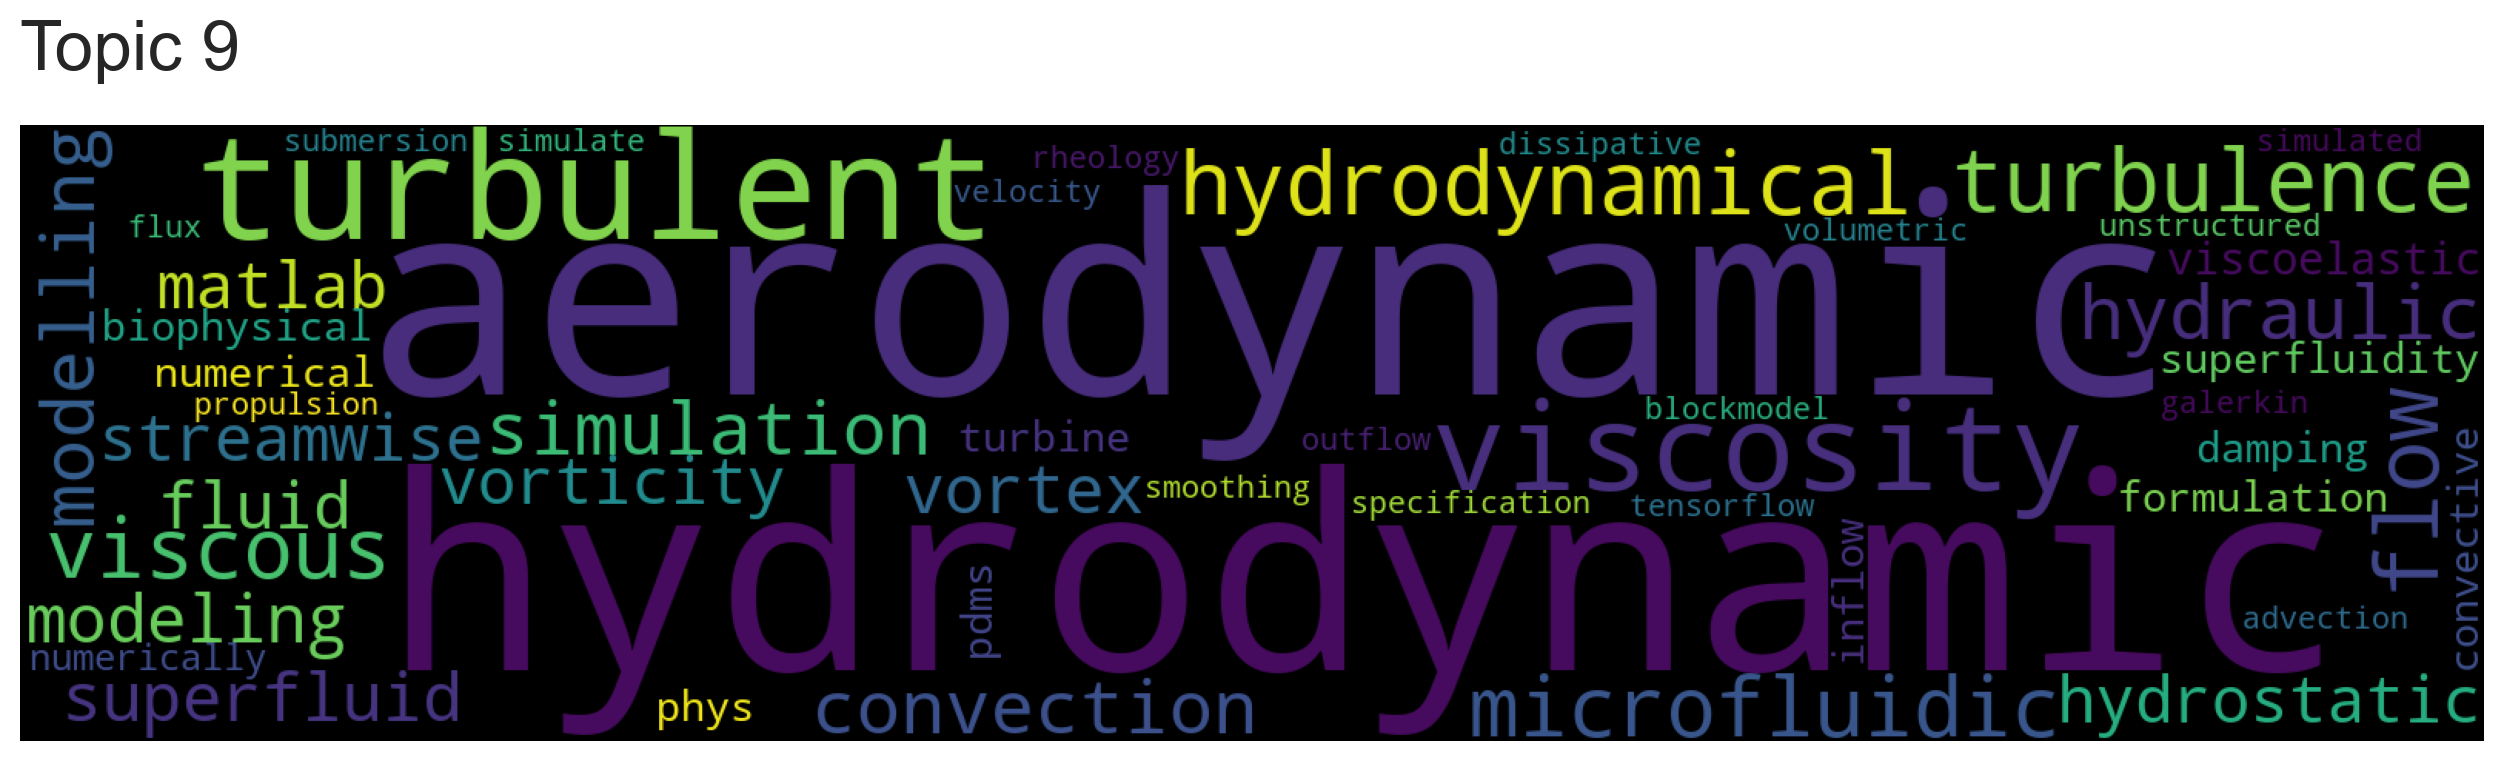

In [59]:
warnings.filterwarnings("ignore", category=DeprecationWarning, module="matplotlib")
for i in range(10):
    best_model.generate_topic_wordcloud(i)

Grafica 2d de los temas representa una proyección bidimensional del espacio de vectores donde están ubicados los topic embeddings, Cada punto es un “tema”, Temas cercanos en el gráfico son conceptualmente similares, no muestra cuántos documentos pertenecen a cada tema

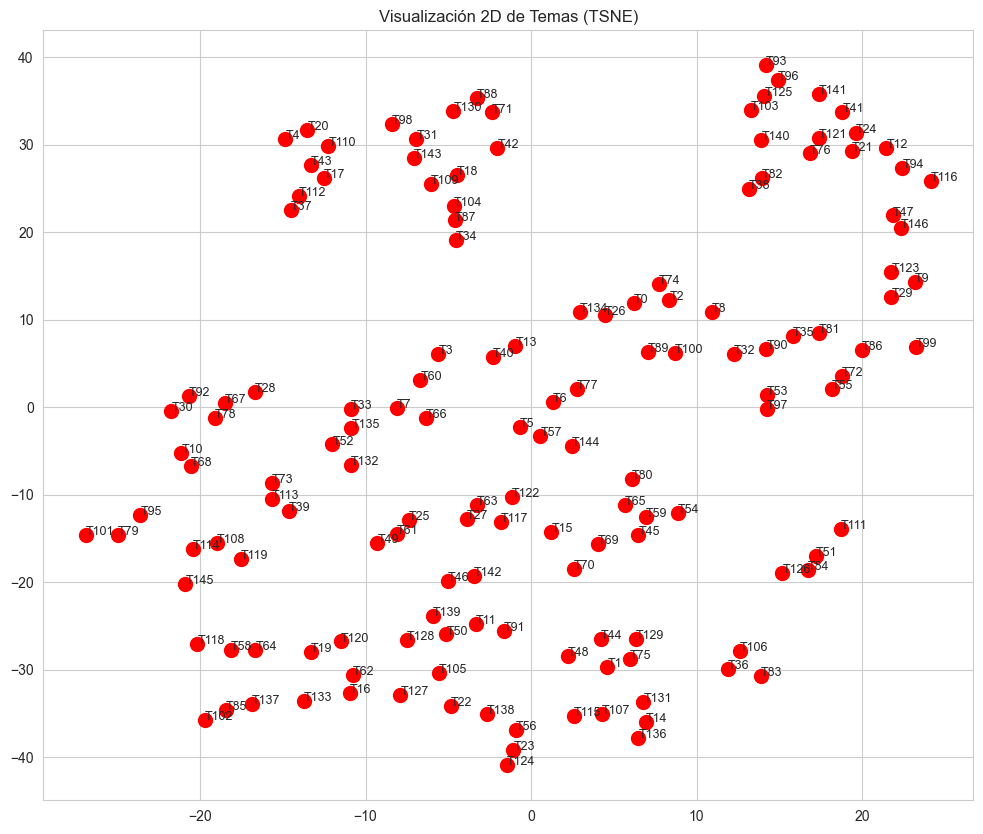

In [56]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

topic_vectors = best_model.topic_vectors

tsne = TSNE(n_components=2, random_state=42, perplexity=10)
proj = tsne.fit_transform(topic_vectors)

plt.figure(figsize=(12,10))
plt.scatter(proj[:,0], proj[:,1], s=100, c="red")

for i,(x,y) in enumerate(proj):
    plt.text(x, y, f"T{i}", fontsize=9)

plt.title("Visualización 2D de Temas (TSNE)")
plt.show()